# Random Forest Forecasting for Time Series Data

This section works with the NYSE dataset. Three time series in this dataset are used: `DJ_return` ($a_t$), `log_volatility` ($b_t$), and `log_volume` ($c_t$). The data was originally obtained from the R library ISLR2, with documentation for the dataset available [here](https://cran.rstudio.com/web/packages/ISLR2/ISLR2.pdf), which explains the meaning of the variables.

The forecasting target is the 1-step ahead value of `log_volume` $c_{t+1}$ using the previous values of this variable and the other two variables (`DJ_return` and `log_volatility`) up to 5 lags. So the features are $c_{t},\dots,c_{t-4},b_{t},\dots,b_{t-4},a_{t},\dots,a_{t-4}$.

The included dataset is loaded from `../data/NYSE.csv`.


In [13]:
import os
import pandas as pd
data = pd.read_csv("../data/NYSE.csv")

## Feature Matrix and Target Construction
Create the feature matrix `X` and the target variable `y`. The notebook prints the first 2 rows of `X` and `y` (it is acceptable that not every element of the rows are printed).


**Solution:**


In [14]:
a = data["DJ_return"]
b = data["log_volatility"]
c = data["log_volume"]

X = pd.DataFrame({
    "c_t": c.shift(0),
    "c_t-1": c.shift(1),
    "c_t-2": c.shift(2),
    "c_t-3": c.shift(3),
    "c_t-4": c.shift(4),
    "b_t": b.shift(0),
    "b_t-1": b.shift(1),
    "b_t-2": b.shift(2),
    "b_t-3": b.shift(3),
    "b_t-4": b.shift(4),
    "a_t": a.shift(0),
    "a_t-1": a.shift(1),
    "a_t-2": a.shift(2),
    "a_t-3": a.shift(3),
    "a_t-4": a.shift(4),
})

y = pd.DataFrame({
    "y": c.shift(-1)
})

# combine & drop NA
df = pd.concat([X, y], axis=1).dropna()

# separate X, Y
X = df.drop(columns="y")
y = df["y"]


print("X first 2 rows:")
print(X.head(2))

print("\ny first 2 rows:")
print(y.head(2))

X first 2 rows:
        c_t     c_t-1     c_t-2     c_t-3     c_t-4        b_t      b_t-1  \
4  0.044187  0.210182  0.525306  0.346202  0.032573 -11.728130 -11.626772   
5  0.133246  0.044187  0.210182  0.525306  0.346202 -10.872526 -11.728130   

       b_t-2      b_t-3      b_t-4       a_t     a_t-1     a_t-2     a_t-3  \
4 -11.665609 -11.749305 -13.127403  0.000568 -0.003462  0.003845  0.007813   
5 -11.626772 -11.665609 -11.749305 -0.010824  0.000568 -0.003462  0.003845   

      a_t-4  
4 -0.004461  
5  0.007813  

y first 2 rows:
4    0.133246
5   -0.011528
Name: y, dtype: float64


## Random Forest Forecasting with TimeSeriesSplit
Consider fitting a random forest to predict the 1-step ahead value of `log_volume`. The random forest must include the argument `random_state=42`, and it is useful to also include `n_jobs=-1` where available, `n_jobs=-1` can be used. Use 3-fold time series CV split, with the test set split 50% into a validation set and 50% into the actual test set, to tune the hyperparameters `n_estimators` taking the values  200, 400, 600, and the cost-complexity pruning parameter $\alpha$ taking the values $10^{-k}$, $k=1,3,5,7$. When tuning hyperparameters on the validation sets, fit the model only on a random 10% sample of the instances of the training set on the same CV fold to reduce computational time (that is, use the same reduced training set for all the hyperparameters, but a different one for each CV fold). Note this will still preserve the correct time ordering, and the reduce training set should not be used when fitting and evaluating the best model on the test set. The performance measure is RMSE. Report the best hyperparameters.


**Solution:**


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

# RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# time series cross-validation
ts_split = TimeSeriesSplit(n_splits=3)

param_grid = []
for n_estimators in [200, 400, 600]:
    for k in [1, 3, 5, 7]:
        param_grid.append((n_estimators, 10**(-k)))

results = []

for fold, (train_idx, holdout_idx) in enumerate(ts_split.split(X), start=1):
    # 50% validation 50% actual test
    mid = len(holdout_idx) // 2
    val_idx = holdout_idx[:mid]
    test_idx = holdout_idx[mid:]

    # use 10% random subsample tuning
    rng = np.random.RandomState(42 + fold)
    reduced_size = int(0.1 * len(train_idx))
    reduced_train_idx = np.sort(
        rng.choice(train_idx, size=reduced_size, replace=False)
    )

    X_train_red = X.iloc[reduced_train_idx]
    y_train_red = y.iloc[reduced_train_idx]
    X_val = X.iloc[val_idx]
    y_val = y.iloc[val_idx]

    # RandomForest
    for n_estimators, ccp_alpha in param_grid:
        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            ccp_alpha=ccp_alpha,
            random_state=67,
            n_jobs=-1
        )

        rf.fit(X_train_red, y_train_red)
        y_val_pred = rf.predict(X_val)
        val_rmse = rmse(y_val, y_val_pred)

        results.append({
            "fold": fold,
            "n_estimators": n_estimators,
            "ccp_alpha": ccp_alpha,
            "val_rmse": val_rmse
        })

results_df = pd.DataFrame(results)

summary_df = (
    results_df
    .groupby(["n_estimators", "ccp_alpha"], as_index=False)["val_rmse"]
    .mean()
    .sort_values("val_rmse")
)

print(summary_df)

best_params = summary_df.iloc[0]
print("\nBest hyperparameters:")
print(best_params)

    n_estimators     ccp_alpha  val_rmse
4            400  1.000000e-07  0.172350
5            400  1.000000e-05  0.172357
8            600  1.000000e-07  0.172454
9            600  1.000000e-05  0.172455
1            200  1.000000e-05  0.173057
0            200  1.000000e-07  0.173081
6            400  1.000000e-03  0.175159
10           600  1.000000e-03  0.175170
2            200  1.000000e-03  0.175875
3            200  1.000000e-01  0.235188
11           600  1.000000e-01  0.235196
7            400  1.000000e-01  0.235209

Best hyperparameters:
n_estimators    4.000000e+02
ccp_alpha       1.000000e-07
val_rmse        1.723498e-01
Name: 4, dtype: float64


## Test Set Forecast Evaluation
Using the same time series split as in (b), compute the RMSE of the best fitting model on the test set, and include a plot of the true values and predicted values on the test set of the last fold (the fold closest to the current time) of the CV.


**Implementation:**


Fold 1 test RMSE: 0.171037
Fold 2 test RMSE: 0.173468
Fold 3 test RMSE: 0.215787


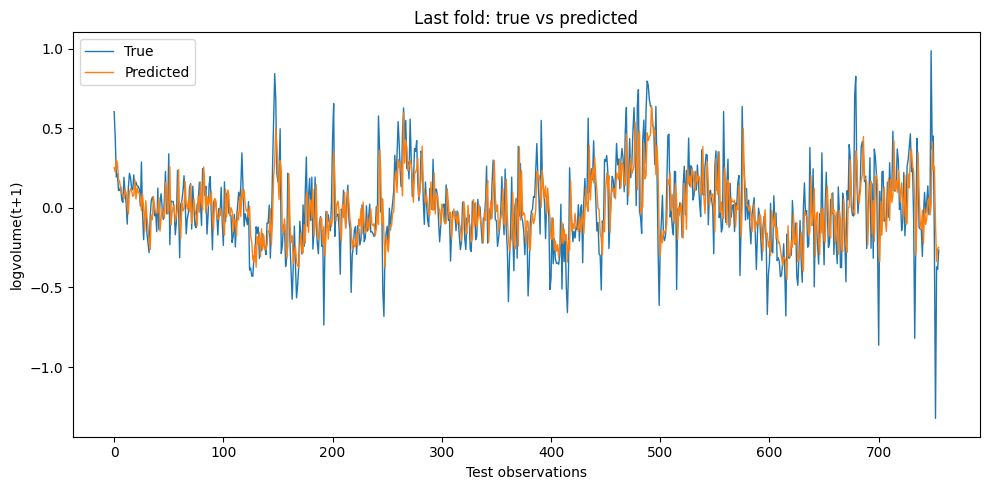

In [ ]:
import matplotlib.pyplot as plt

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Best hyperparameters from (b)
best_n_estimators = 400
best_ccp_alpha = 1e-7

ts_split = TimeSeriesSplit(n_splits=3)

test_rmse_list = []

for fold, (train_idx, holdout_idx) in enumerate(ts_split.split(X), start=1):
    mid = len(holdout_idx) // 2
    val_idx = holdout_idx[:mid]
    test_idx = holdout_idx[mid:]

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    rf_best = RandomForestRegressor(
        n_estimators=best_n_estimators,
        ccp_alpha=best_ccp_alpha,
        random_state=67,
        n_jobs=-1
    )

    rf_best.fit(X_train, y_train)
    y_test_pred = rf_best.predict(X_test)

    test_rmse = rmse(y_test, y_test_pred)
    test_rmse_list.append(test_rmse)

    print(f"Fold {fold} test RMSE: {test_rmse:.6f}")

    # Plot the last fold
    if fold == 3:
        plt.figure(figsize=(10, 5))
        plt.plot(y_test.values, label="True", linewidth=1)
        plt.plot(y_test_pred, label="Predicted", linewidth=1)
        plt.xlabel("Test observations")
        plt.ylabel("logvolume(t+1)")
        plt.title("Last fold: true vs predicted")
        plt.legend()
        plt.tight_layout()
        plt.show()

## Baseline Forecast Comparison
It is often useful to check that the model is not worse than a very simple method of prediction. On the test set, compute the RMSE of a model that simply predicts the 1-step ahead value of `log_volume` $c_{t+1}$ as the current value $c_t$, and compare this to the best fitting random forest model.


**Implementation:**


In [ ]:
naive_rmse_list = []
rf_rmse_list = []

for fold, (train_idx, holdout_idx) in enumerate(ts_split.split(X), start=1):
    mid = len(holdout_idx) // 2
    test_idx = holdout_idx[mid:]

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    rf_best = RandomForestRegressor(
        n_estimators=best_n_estimators,
        ccp_alpha=best_ccp_alpha,
        random_state=67,
        n_jobs=-1
    )
    rf_best.fit(X_train, y_train)
    y_pred_rf = rf_best.predict(X_test)

    y_pred_naive = X_test["c_t"]

    rf_rmse = rmse(y_test, y_pred_rf)
    naive_rmse = rmse(y_test, y_pred_naive)

    rf_rmse_list.append(rf_rmse)
    naive_rmse_list.append(naive_rmse)

    print(f"Fold {fold}: RF RMSE = {rf_rmse:.6f}, Naive RMSE = {naive_rmse:.6f}")

print("Average RF RMSE:", np.mean(rf_rmse_list))
print("Average Naive RMSE:", np.mean(naive_rmse_list))

Fold 1: RF RMSE = 0.171037, Naive RMSE = 0.193708
Fold 2: RF RMSE = 0.173468, Naive RMSE = 0.203234
Fold 3: RF RMSE = 0.215787, Naive RMSE = 0.253460
Average RF RMSE: 0.18676390957746714
Average Naive RMSE: 0.21680067783845988


## Feature Importance Analysis
Compute the feature importances of the best fitting model. The feature importances are used to identify the most influential predictor.


**Solution:**


In [28]:
feature_importances = pd.Series(rf_best.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

print(feature_importances)
print("\nMost important feature:", feature_importances.index[0])
print("Importance value:", feature_importances.iloc[0])

c_t      0.538689
c_t-3    0.060307
a_t      0.060217
c_t-4    0.053864
a_t-1    0.041926
c_t-2    0.038974
a_t-2    0.036537
c_t-1    0.036285
a_t-4    0.032386
a_t-3    0.030819
b_t      0.015598
b_t-4    0.015495
b_t-1    0.014038
b_t-3    0.012855
b_t-2    0.012010
dtype: float64

Most important feature: c_t
Importance value: 0.5386893885978951


The most important feature is `c_t`, with a feature importance value of 0.5386893885978951.


# Time Series Signatures

In class, we discussed how time series signatures can capture the order-dependent interaction structure of multivariate time series. In this practice example, we extend that idea to show how path signatures can be used to identify lead–lag relationships between multiple time series.

As we discussed in the previous lecture, the level-2 signature captures pairwise interactions:

$$S^{(2)}_{XY} = \int dX\,dY, \quad
S^{(2)}_{YX} = \int dY\,dX$$

The *antisymmetric part* is:

$$A_{XY} = S^{(2)}_{XY} - S^{(2)}_{YX}$$

This quantity is known as the *signed area (Lévy area)*.

We can interpret this quantity as:
- $A_{XY} > 0$: X leads Y  
- $A_{XY} < 0$: Y leads X  

We will verify this numerically using simulated data:


In [22]:
import numpy as np

np.random.seed(42)

n = 300
t = np.linspace(0, 4*np.pi, n)

noise_x = 0.08 * np.random.randn(n)
noise_y = 0.08 * np.random.randn(n)

# Case A: X leads Y
X_A = np.sin(t) + noise_x
Y_A = np.sin(t - 0.7) + noise_y

# Case B: Y leads X
X_B = np.sin(t - 0.7) + noise_x
Y_B = np.sin(t) + noise_y

# Build paths (important: include time!)
path_A = np.column_stack([t, X_A, Y_A])
path_B = np.column_stack([t, X_B, Y_B])

Let's visualize the two trajectories:


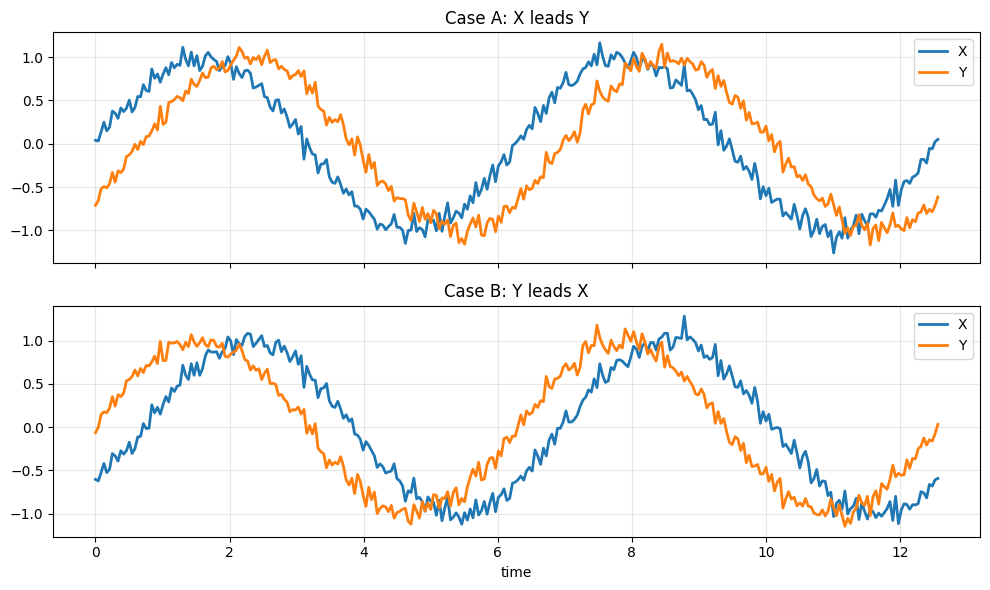

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10,6), sharex=True)

# Case A
axes[0].plot(t, X_A, label='X', linewidth=2)
axes[0].plot(t, Y_A, label='Y', linewidth=2)
axes[0].set_title("Case A: X leads Y")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Case B
axes[1].plot(t, X_B, label='X', linewidth=2)
axes[1].plot(t, Y_B, label='Y', linewidth=2)
axes[1].set_title("Case B: Y leads X")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.xlabel("time")
plt.tight_layout()
plt.show()

The first 150 steps of the raw comovements in each case can also be visualized. Path A and path B evolve in different directions.


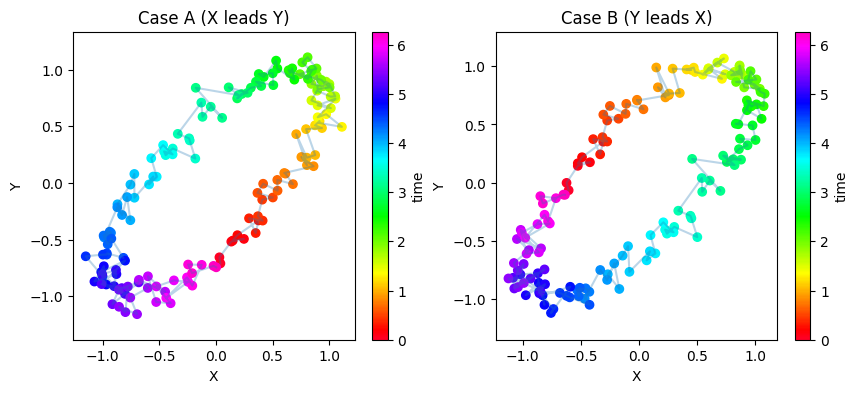

In [24]:
def plot_with_time_color(x, y, t, title):
    sc = plt.scatter(x, y, c=t, cmap='gist_rainbow')
    plt.colorbar(sc, label='time')
    plt.plot(x, y, alpha=0.3)
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis("equal")
    
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plot_with_time_color(X_A[:150], Y_A[:150], t[:150], "Case A (X leads Y)")

plt.subplot(1,2,2)
plot_with_time_color(X_B[:150], Y_B[:150], t[:150], "Case B (Y leads X)")

plt.show()

## Level-2 Signature Features
Compute the level-2 signature (`sig_level = 2`) for Path A and Path B.  
The `iisignature` package may need to be installed if it is not already available. Print the resulting signature vectors.


**Solution:**


In [31]:
# For a 3D path (t, X, Y),  
# signature entries up to level-2 are ordered as: 
# [t, X, Y, tt, tX, tY, Xt, XX, XY, Yt, YX, YY] 
import iisignature

sig_A = iisignature.sig(path_A, 2)
sig_B = iisignature.sig(path_B, 2)

print("Signature of Path A:")
print(sig_A)

print("\nSignature of Path B:")
print(sig_B)

Signature of Path A:
[ 1.25663706e+01  1.06331751e-02  9.65036403e-02  7.89568352e+01
  6.40462143e-01 -7.69525740e+00 -5.06841724e-01  5.65322065e-05
  4.11502148e+00  8.90795791e+00 -4.11399534e+00  4.65647630e-03]

Signature of Path B:
[ 1.25663706e+01  1.06331751e-02  9.65036403e-02  7.89568352e+01
 -7.45501607e+00  4.00220815e-01  7.58863649e+00  5.65322065e-05
 -3.97081689e+00  8.12479695e-01  3.97184303e+00  4.65647630e-03]


## Signed Area and Lead-Lag Interpretation
Compute the signed area 
$$A_{XY} = S^{(2)}_{XY} - S^{(2)}_{YX}.$$
Based on its sign, briefly explain what this implies about the lead–lag relationship between \(X\) and \(Y\).


**Solution:**


In [32]:
A_XY_A = sig_A[8] - sig_A[10]
A_XY_B = sig_B[8] - sig_B[10]

print("Signed area for Path A:", A_XY_A)
print("Signed area for Path B:", A_XY_B)

Signed area for Path A: 8.22901682856005
Signed area for Path B: -7.942659923415005


## Signature Dimension at Higher Levels
How does the dimension of the signature change if the signature level is increased to 3? Explain the result.


**Solution:**


Since the path is 3-dimensional (t, X, Y), the signature dimension up to level 3 is  
3 + 3^2 + 3^3 = 3 + 9 + 27 = 39  
Therefore, the dimension increases from 12 at level 2 to 39 at level 3.


# SVM Classification

For all SVM models in this section use a standard scaler.

## Linear SVM Hyperparameter Search
In this section, a SVM is used for classification for the MNIST dataset. The following code loads the MNIST dataset, creates the test set, and to reduce training time, takes a random sample of 2000  from the full training set to use as the working training set stored in `X` and `y`. The data order is preserved.

Hint: Reading the solution to the related textbook example in the Chapter 5 [Jupyter notebook](https://github.com/ageron/handson-ml2/blob/master/05_support_vector_machines.ipynb) (2nd edition) on the textbook website may help with this section.


In [ ]:
import numpy as np
import matplotlib as mlp
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False, cache=True, parser='auto')
X_train = mnist["data"][:60000]
X_test  = mnist["data"][60000:]
y_train = mnist["target"][:60000]
y_test  = mnist["target"][60000:]

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

N = 2000
split_obj = StratifiedShuffleSplit(n_splits=1,
                               test_size=N/60000, random_state=42)
for other_idx, subsample_idx in split_obj.split(X_train, y_train):
    X = X_train[subsample_idx]
    y = y_train[subsample_idx]

**Practice focus:** Consider fitting the linear SVM classifier (`LinearSVC`) with `max_iter=50000`. For this model, optimize the hyperparameter $C$ using 3-fold CV over the values $10^{-k}$, $k=0,1,\dots,9$, where the performance measure is accuracy. What is the best $C$ and what is the accuracy in this case?


**Solution:**


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    "linearsvc__C": [10**(-k) for k in range(10)]
}

lin_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("linearsvc", LinearSVC(max_iter=50000, random_state=42))
])

grid_search_lin = GridSearchCV(
    lin_svm,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_lin.fit(X, y)

print("Best C:", grid_search_lin.best_params_["linearsvc__C"])
print("Best CV accuracy:", grid_search_lin.best_score_)

Best C: 0.01
Best CV accuracy: 0.8329911620766194


## RBF Kernel SVM Hyperparameter Search
**Practice focus:** Now consider fitting a SVM with a Gaussian RBF kernel and `max_iter=50000`. For this model, optimize the hyperparameters $C$ over the distrbution `uniform(1,10)` and $\gamma$ over the distribution `loguniform(0.0001, 0.1)` from `scipy.stats.loguniform` with 10 random samples. The `loguniform(a,b)` function takes a random sample from the probability distribution with pdf $f(x)\propto 1/x, x\in[a,b]$. Again, use 3-fold CV and the performance measure is accuracy. What are the best hyperparameters and what is the accuracy in this case?


**Solution:**


In [36]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

rbf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", max_iter=50000, random_state=42))
])

param_dist = {
    "svc__C": uniform(1, 10),
    "svc__gamma": loguniform(0.0001, 0.1)
}

random_search_rbf = RandomizedSearchCV(
    rbf_svm,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search_rbf.fit(X, y)

print("Best hyperparameters:", random_search_rbf.best_params_)
print("Best CV accuracy:", random_search_rbf.best_score_)

Best hyperparameters: {'svc__C': np.float64(9.324426408004218), 'svc__gamma': np.float64(0.0004335281794951569)}
Best CV accuracy: 0.8904999452225839


## Best SVM Test Accuracy
**Practice focus:** Choose the best model in (a) and (b). Then for this model, evaluate the accuracy on the test set, which is stored in `X_test` and `y_test`.


**Solution:**


In [37]:
from sklearn.metrics import accuracy_score

best_model = random_search_rbf.best_estimator_
y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("Chosen model: RBF SVM")
print("Test accuracy:", test_acc)

Chosen model: RBF SVM
Test accuracy: 0.909


Since the RBF SVM achieved a higher cross-validation accuracy (0.8904999452225839) than the linear SVM (0.8329911620766194), the RBF SVM is selected as the best model and evaluated on the test set.


# Voting Classifiers
## Base Classifiers for MNIST
Consider the MNIST dataset. To save computational time, after spliting into a training, validation and test set, we keep only the first 5000 instances of the training set, and only the first 1000 instances of the validation and test set, as given by the following code.


In [ ]:
N = 50_000
M = 60_000
X_train = mnist["data"][:N][:5000]
y_train = mnist["target"][:N][:5000]
X_valid  = mnist["data"][N:M][:1000]
y_valid = mnist["target"][N:M][:1000]
X_test  = mnist["data"][M:][:1000]
y_test = mnist["target"][M:][:1000]

The data order is preserved, and no standard scaler is used. The following classifiers are trained on the training set:

(i) a multilayer perceptron classifier using the class `MLPClassifier()` from `sklearn.neural_network` with arguments `random_state=42`,

(ii) an extra-trees classifier with arguments `n_estimators=100, n_jobs=-1, random_state=42`,

(iii) an AdaBoost classifier  with arguments  `n_estimators=50, learning_rate=0.2, random_state=42`,

(iv) a gradient boosting classifier using the class `GradientBoostingClassifier()` with arguments `max_depth=2, n_estimators=10, learning_rate=0.25, random_state=42`.

Report the accuracy of each trained classifier on the validation set.

Hint: Reading the solution to the related textbook example in the Chapter 7 [Jupyter notebook](https://github.com/ageron/handson-ml3/blob/main/07_ensemble_learning_and_random_forests.ipynb) on the textbook website may help with this section.


**Solution:**


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Multilayer perceptron classifier
mlp_clf = MLPClassifier(random_state=42)
# Extra-trees classifier
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, n_jobs=-1, random_state=42)
# AdaBoost classifier
ada_clf = AdaBoostClassifier(n_estimators=50, learning_rate=0.2, random_state=42)
# Gradient boosting classifier
gb_clf = GradientBoostingClassifier(max_depth=2, n_estimators=10, learning_rate=0.25, random_state=42)

models = {
    "MLP": mlp_clf,
    "Extra Trees": extra_trees_clf,
    "AdaBoost": ada_clf,
    "Gradient Boosting": gb_clf
}

valid_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_valid_pred = model.predict(X_valid)
    acc = accuracy_score(y_valid, y_valid_pred)
    valid_scores[name] = acc
    print(f"{name} validation accuracy: {acc}")

MLP validation accuracy: 0.889
Extra Trees validation accuracy: 0.944
AdaBoost validation accuracy: 0.431
Gradient Boosting validation accuracy: 0.802


## Hard and Soft Voting Ensembles
Train the following models:

* a hard-voting ensemble classifier for all the models in (a)
* a soft-voting ensemble classifier for all the models in (a)
* a hard-voting ensemble classifier dropping the worst performing model in (a)
* a soft-voting ensemble classifier dropping the worst performing model in (a)

Evaluate the accuracy of these voting classifiers on the validation set, and compare it to the performance of the individual models in (a).


In [ ]:
from sklearn.ensemble import VotingClassifier

worst_model = min(valid_scores, key=valid_scores.get)
print("Worst model from (a):", worst_model)

estimators_all = [
    ("mlp", mlp_clf),
    ("extra", extra_trees_clf),
    ("ada", ada_clf),
    ("gb", gb_clf)
]

estimators_drop = [est for est in estimators_all if est[0] != {
    "MLP": "mlp",
    "Extra Trees": "extra",
    "AdaBoost": "ada",
    "Gradient Boosting": "gb"
}[worst_model]]

voting_hard_all = VotingClassifier(estimators=estimators_all, voting="hard")
voting_soft_all = VotingClassifier(estimators=estimators_all, voting="soft")
voting_hard_drop = VotingClassifier(estimators=estimators_drop, voting="hard")
voting_soft_drop = VotingClassifier(estimators=estimators_drop, voting="soft")

voting_models = {
    "Hard voting (all)": voting_hard_all,
    "Soft voting (all)": voting_soft_all,
    "Hard voting (drop worst)": voting_hard_drop,
    "Soft voting (drop worst)": voting_soft_drop
}

voting_scores = {}

for name, model in voting_models.items():
    model.fit(X_train, y_train)
    y_valid_pred = model.predict(X_valid)
    acc = accuracy_score(y_valid, y_valid_pred)
    voting_scores[name] = acc
    print(f"{name} validation accuracy: {acc}")

Worst model from (a): AdaBoost
Hard voting (all) validation accuracy: 0.896
Soft voting (all) validation accuracy: 0.899
Hard voting (drop worst) validation accuracy: 0.916
Soft voting (drop worst) validation accuracy: 0.899


**Solution:**


## Best Ensemble Test Accuracy
Of the four voting classifiers in (b), choose the best model. Then evaluate the accuracy of this model on the test set.


**Solution:**


In [41]:
best_voting_name = max(voting_scores, key=voting_scores.get)
best_voting_model = voting_models[best_voting_name]

y_test_pred = best_voting_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("Best voting classifier:", best_voting_name)
print("Validation accuracy:", voting_scores[best_voting_name])
print("Test accuracy:", test_acc)

Best voting classifier: Hard voting (drop worst)
Validation accuracy: 0.916
Test accuracy: 0.904


# Stacking Ensemble

We continue with the setting of the voting-classifier section. The training set, validation set and test set are the same. In the voting-classifier section, we have used predetermined rules (that is, hard-voting and soft-voting) to build the ensemble prediction. **Stacking** is an ensemble method in which a model (called a **blender**) is trained to aggregate the result of each predictor into an ensemble prediction.

Hint: Reading the subsection "Stacking" in Chapter 7 of the textbook and the solution to the related textbook example in the Chapter 7 [Jupyter notebook](https://github.com/ageron/handson-ml3/blob/main/07_ensemble_learning_and_random_forests.ipynb) on the textbook website may help with this section.

## Stacking Feature Construction
For each of the four classifiers in the base-classifier section, make 5000 clean predictions on the training set with 3-fold cross validation using `sklearn.model_selection.cross_val_predict()`. It is useful to end up with four predictions per observation. The notebook prints the first 5 rows of `pred`. Next, apply one-hot encoding to `pred` since these predictions are class labels.


**Solution:**


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np

pred_mlp = cross_val_predict(mlp_clf, X_train, y_train, cv=3, n_jobs=-1)
pred_extra = cross_val_predict(extra_trees_clf, X_train, y_train, cv=3, n_jobs=-1)
pred_ada = cross_val_predict(ada_clf, X_train, y_train, cv=3, n_jobs=-1)
pred_gb = cross_val_predict(gb_clf, X_train, y_train, cv=3, n_jobs=-1)

pred = np.column_stack([pred_mlp, pred_extra, pred_ada, pred_gb])
pred_df = pd.DataFrame(pred, columns=["MLP", "ExtraTrees", "AdaBoost", "GradientBoosting"])

print(pred_df[:5])

# apply one-hot encoding to pred
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
pred_encoded = encoder.fit_transform(pred_df)

  MLP ExtraTrees AdaBoost GradientBoosting
0   5          5        0                3
1   0          0        0                0
2   4          4        7                4
3   1          1        1                1
4   9          9        4                9


## Blender Model Training
Use the predictions in (a) as features and the actual label of the observations as the target. Train a random forest classifier on the training set with the parameters `n_estimators=100, random_state=42`.  This classifier is a blender.


**Solution:**


In [44]:
from sklearn.ensemble import RandomForestClassifier

blender = RandomForestClassifier(n_estimators=100, random_state=42)
blender.fit(pred_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Blender Test Set Evaluation
Obtain the predictions of the blender on the test set by feeding predictions on the test set from the four classifiers in the base-classifier section into the blender trained in the blender training section. The blender is not retrained. These are called stacking predictions. Report the accuracy of the stacking predictions on the test set and compare this to the results in the best ensemble evaluation section.


**Solution:**


In [45]:
from sklearn.metrics import accuracy_score

test_pred_mlp = mlp_clf.predict(X_test)
test_pred_extra = extra_trees_clf.predict(X_test)
test_pred_ada = ada_clf.predict(X_test)
test_pred_gb = gb_clf.predict(X_test)

pred_test = np.column_stack([test_pred_mlp, test_pred_extra, test_pred_ada, test_pred_gb])
pred_test_df = pd.DataFrame(pred_test, columns=["MLP", "ExtraTrees", "AdaBoost", "GradientBoosting"])

pred_test_encoded = encoder.transform(pred_test_df)

stacking_pred = blender.predict(pred_test_encoded)
stacking_acc = accuracy_score(y_test, stacking_pred)

print("Stacking test accuracy:", stacking_acc)

Stacking test accuracy: 0.93
